# FIP 01 — Movement (motion energy) × RPE / value coding

Extends `fip_00_explore.ipynb`'s single-session FIP + motion-energy (ME) pipeline with the
analysis used for the FIP-only tonic-value / phasic-RPE figure (baseline AUC by consecutive
reward streak, outcome traces by RPE bin), applied to motion energy across all example FIP
channels. Two figures:

1. Session-averaged movement over time per RPE bin
2. Z-scored AUC per consecutive R-/R+ (`num_reward_past`)

Recipe traced directly from `rachel-analysis-utils`, `aind-dynamic-foraging-basic-analysis`,
`aind-dynamic-foraging-data-utils`, and (for the plotting conventions) the `DA_phasic_tonic`
repo — see the implementation plan (`fip_01` plan, 2026-09-14) for the full trace and the
deviations reviewed against that source. Setup (loading, curation, session select, trial
enrichment, example channels, motion energy) comes from the shared `fip_utils.py` module,
which `fip_00_explore.ipynb` and `fip_02_ne_only_events.ipynb` also use.

A third figure (NE-only onsets aligned to movement) originally lived here; it moved to
`fip_02_ne_only_events.ipynb`, which compares NE and DA transients directly rather than
treating all NE onsets alike.

## Imports & setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Shared fip_* setup: loading, curation, session select, trial enrichment, example channels,
# motion energy on the FIP clock. autoreload so editing fip_utils.py doesn't cost a kernel
# restart + a full session reload.
%load_ext autoreload
%autoreload 2
import fip_utils as fu

# FIP enrichment helpers (z-scoring, per-trial windowing, tonic/baseline removal) -- the same
# functions Rachel's own pipeline uses, not a reimplementation of them.
from aind_dynamic_foraging_data_utils import enrich_dfs

# Upstream PSTH-by-category plotter, reused for the RPE-binned movement panel (Figure 1).
from aind_dynamic_foraging_basic_analysis.plot import plot_fip as pf

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)


## Data loading and curation

`fu.load_curated_sessions` wraps `load_nwb_list` + `apply_curation_nwb_list`, including the
patch for `data_curation_helpers.apply_curation_nwb_list`'s missing private-helper imports (an
upstream bug) and the `drop_borderline=False` / free-the-raw-list memory fix.


In [2]:
nwb_list = fu.load_curated_sessions()


plot_loc = /root/capsule/data/DA_NE_4channels/
loading 7 df_sess file(s)
no bg_coef files found at plot location, skipping
no rpe_slope.csv found at plot location, skipping
loading 808054_2025-09-02
loading 808054_2025-09-03
loading 808054_2025-09-04
loading 808054_2025-09-05
loading 808054_2025-09-08
loading 808054_2025-09-09
loading 808054_2025-09-10
loading 808054_2025-09-11
loading 808054_2025-09-12
loading 808054_2025-09-15
loading 808054_2025-09-16
loading 808054_2025-09-17
loading 808054_2025-09-18
loading 808054_2025-09-19
loading 808054_2025-09-22
loading 808054_2025-09-23
loading 808054_2025-09-24
loading 808054_2025-09-25
loading 808054_2025-09-26
loading 808054_2025-10-02
loading 808054_2025-10-07
loading 808054_2025-10-08
loading 808054_2025-10-10
loading 808054_2025-10-13
loading 808054_2025-10-14
loading 808054_2025-10-15
loading 808054_2025-10-16
loading 808054_2025-10-17
loading 808056_2025-09-12
loading 808056_2025-09-15
loading 808056_2025-09-16
loading 808056_2025-0

## Data processing

### Select a session and build the signal table

Same example session as `fip_00_explore.ipynb` (`SESSION_IDX = 0`).
`require_trial_zero_gocue=True` additionally asserts `goCue_start_time_in_trial == 0` for every
trial, because `enrich_fip_in_df_trials`'s per-trial window math (below) assumes the go cue is
trial-local time zero.


In [3]:
SESSION_IDX = 0
nwb, df_fip, df_trials = fu.select_session(nwb_list, SESSION_IDX, require_trial_zero_gocue=True)


session_id: 808054_2025-09-02 | df_fip (629134, 11) | trials (524, 113)


In [4]:
meta = fu.build_meta(df_fip)
print(f"{len(meta)} FIP series (pearsonR excluded)")
meta


5 FIP series (pearsonR excluded)


,event,channel,fiber,variant,region
0,G_0_dff-bright_mc-iso-IRLS,G,0,dff-bright_mc-iso-IRLS,NAc(L)-dLight
1,G_2_dff-bright_mc-iso-IRLS,G,2,dff-bright_mc-iso-IRLS,PL(R)-Gcamp
2,G_3_dff-bright_mc-iso-IRLS,G,3,dff-bright_mc-iso-IRLS,NAc(R)-dLight
3,R_2_dff-bright_mc-iso-IRLS,R,2,dff-bright_mc-iso-IRLS,NAc(R)-rAch
4,R_3_dff-bright_mc-iso-IRLS,R,3,dff-bright_mc-iso-IRLS,NAc(L)-rAch


### Trial enrichment — `num_reward_past` and `RPE-binned3`

`fu.enrich_trials` calls `rachel_analysis_utils.analysis_utils.enrich_df_trials`, the source of
both columns.


In [5]:
df_trials = fu.enrich_trials(df_trials)
nwb.df_trials = df_trials

RPE_binned3_label_names = df_trials["RPE-binned3"].cat.categories.astype(str).tolist()
print("RPE-binned3 categories:", RPE_binned3_label_names)
df_trials[["num_reward_past", "RPE-binned3"]].describe(include="all")


Used rachel_analysis_utils.analysis_utils.enrich_df_trials directly.
RPE-binned3 categories: ['-1.0', '-0.67', '-0.33', '-0.0', '0.33', '0.67']


,num_reward_past,RPE-binned3
count,524.000000,518
unique,NaN,6
top,NaN,-0.33
freq,NaN,145
mean,-0.814885,NaN
std,3.517518,NaN
min,-17.000000,NaN
25%,-2.000000,NaN
50%,-1.000000,NaN
75%,1.000000,NaN


### Example signals

All three example FIP channels used in `fip_00_explore.ipynb` (NAc DA/dLight, PL/GCaMP,
NAc ACh/rAch), same `pick_example` selection logic.

In [6]:
examples = fu.pick_examples(meta, df_fip)
pd.DataFrame(examples)[["label", "event", "channel", "region", "variant", "color"]]


,label,event,channel,region,variant,color
0,NAc DA (dLight),G_0_dff-bright_mc-iso-IRLS,G,NAc(L)-dLight,dff-bright_mc-iso-IRLS,#2ca02c
1,PL (GCaMP),G_2_dff-bright_mc-iso-IRLS,G,PL(R)-Gcamp,dff-bright_mc-iso-IRLS,#1f77b4
2,NAc ACh (rAch),R_2_dff-bright_mc-iso-IRLS,R,NAc(R)-rAch,dff-bright_mc-iso-IRLS,#d62728


### Motion energy on the FIP clock

Motion energy comes from the aligned ME table (the `fip_motion_energy_aligned` asset, built by
`build_me_table.py`), which holds each video frame's Harp time as corrected by the library's
video timing QC. `fu.motion_energy_to_session` divides each value by the exposures it spans
(two after a dropped frame), resamples it onto an even grid at the camera rate, and subtracts the
first go cue, which puts it on the same clock as `df_fip['timestamps']`. Cameras the table
refused (Harp clock steps, trigger-log count mismatches) raise `fu.MotionEnergyRefused`.

The trace is cut to the task, `fu.ME_TASK_PAD_S` (30 s) before the first go cue to 30 s after the last, so movement during setup does not set the scale of any z-score taken over it.


In [7]:
# This session's row in the aligned ME table: timing action, frames lost, and status.
me_info = fu.load_me_index().query("ses_idx == @nwb.session_id and camera == 'BottomCamera'")
me_info[["session", "action", "status", "frames_lost", "error"]]


,session,action,status,frames_lost,error
10,behavior_808054_2025-09-02_10-38-37,use harp as written,ok,0,NaN


In [8]:
t_me, me, offset = fu.motion_energy_to_session(nwb.session_id, df_trials)

# Verify before trusting: offset small & positive, ME/FIP time ranges overlap.
print(f"offset = {offset:.3f} s | ME {t_me.min():.1f}..{t_me.max():.1f}s | "
      f"FIP {df_fip['timestamps'].min():.1f}..{df_fip['timestamps'].max():.1f}s")


offset = 607.039 s | ME -607.0..4884.5s | FIP -1.0..4493.5s


### Attach ME + run the real baseline/tonic-normalization pipeline

`fu.attach_me_to_df_fip` stores **raw** motion energy (not pre-z-scored) so ME flows through
`zscore_fip` / `enrich_fip_in_df_trials` / `remove_tonic_df_fip` exactly like a real FIP
channel -- these are Rachel's actual functions
(`aind_dynamic_foraging_data_utils.enrich_dfs`), channel-agnostic, run once over the whole
`df_fip` (every real channel + `"ME"` together). Produces `data_z` (per `(session, event)`
z-score) and, per trial, `data_z_{event}_baseline` (mean over the 1s immediately before that
trial's go cue) and `data_z_{event}_norm` (baseline-subtracted).


In [9]:
df_fip = fu.attach_me_to_df_fip(df_fip, t_me, me, nwb.session_id)

# enrich_fip_in_df_trials z-scores internally (via zscore_fip) before windowing, so a separate
# upfront zscore_fip call isn't needed.
df_fip_z, df_trials_fip = enrich_dfs.enrich_fip_in_df_trials(df_fip, df_trials)
df_fip_tonic, df_trials, df_trials_fip = enrich_dfs.remove_tonic_df_fip(
    df_fip_z, df_trials, df_trials_fip)

nwb.df_fip = df_fip_z
nwb.df_trials = df_trials

# One pass produces baseline/norm columns for every channel in df_fip at once (channel-agnostic
# -- see title-cell plan note); check them all here, right after the pipeline runs, rather than
# failing deep inside a plotting loop later.
_baseline_cols = [f"data_z_{ex['event']}_baseline" for ex in examples] + ["data_z_ME_baseline"]
for _col in _baseline_cols:
    assert _col in df_trials.columns, f"missing {_col}"
print("baseline columns ready:", _baseline_cols)


baseline columns ready: ['data_z_G_0_dff-bright_mc-iso-IRLS_baseline', 'data_z_G_2_dff-bright_mc-iso-IRLS_baseline', 'data_z_R_2_dff-bright_mc-iso-IRLS_baseline', 'data_z_ME_baseline']


## Figure 1 — session-averaged movement per RPE bin, all signals

One panel per signal (the 3 example FIP channels + motion energy). Same function, alignment
event, time window, censoring, and mako-by-ascending-bin color convention as `DA_phasic_tonic`'s
`PAC_2026.ipynb` recipe for the DA-channel version of this panel -- now looped over every
signal instead of just ME.

  RPE -1.0: 47 trials
  RPE -0.67: 92 trials
  RPE -0.33: 145 trials
  RPE -0.0: 64 trials
  RPE 0.33: 74 trials
  RPE 0.67: 96 trials


/src/aind-dynamic-foraging-basic-analysis/src/aind_dynamic_foraging_basic_analysis/plot/plot_fip.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/src/aind-dynamic-foraging-basic-analysis/src/aind_dynamic_foraging_basic_analysis/plot/plot_fip.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/src/aind-dynamic-foraging-basic-analysis/src/aind_dynamic_foraging_basic_analysis/plot/plot_fip.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


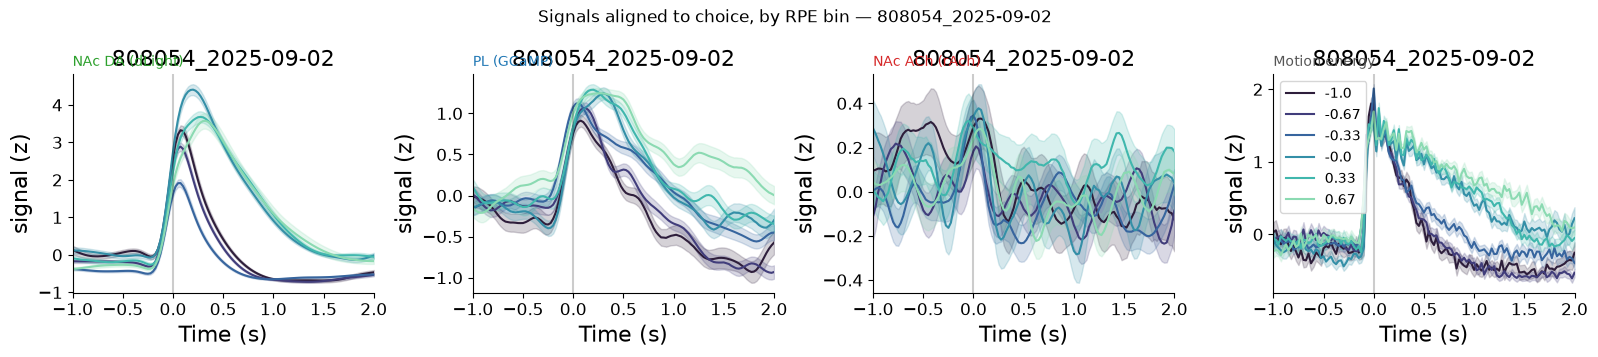

In [10]:
rpe_dict = {
    label: df_trials.loc[df_trials["RPE-binned3"] == label, "choice_time_in_session"].dropna().to_numpy()
    for label in RPE_binned3_label_names
}
for label, times in rpe_dict.items():
    print(f"  RPE {label}: {len(times)} trials")

rpe_colors = dict(zip(RPE_binned3_label_names,
                      sns.color_palette("mako", len(RPE_binned3_label_names)).as_hex()))

plot_signals = examples + [{"label": "Motion energy", "event": "ME", "color": "#555555"}]

fig, axes = plt.subplots(1, len(plot_signals), figsize=(4 * len(plot_signals), 3.6), sharex=True)
for ax, sig in zip(np.atleast_1d(axes), plot_signals):
    pf.plot_fip_psth_compare_alignments(
        nwb, rpe_dict, channel=sig["event"], tw=[-1, 2], censor=True,
        data_column="data_z", extra_colors=rpe_colors, ax=ax, fig=fig)
    ax.set_title(sig["label"], loc="left", fontsize=10, color=sig["color"])
    ax.set_ylabel("signal (z)")
fig.suptitle(f"Signals aligned to choice, by RPE bin — {nwb.session_id}")
fig.tight_layout()
plt.show()

## Figure 2 — z-scored AUC per consecutive R-/R+, all signals

`num_reward_past_baseline = num_reward_past.shift(1)` pairs each trial's baseline value with
the reward-streak count *before* it was recorded (the `power_analysis.ipynb` /
`BWNM_explore_data.ipynb` convention -- mathematically the same pairing
`foraging_summary_plots.py::plot_baseline_corr` gets by shifting baseline the other way). Same
`sns.barplot(..., palette="vlag", hue=..., dodge=False)` recipe as that function's "Column 0",
applied to the real `remove_tonic_df_fip` baseline columns -- one panel per signal (the 3
example FIP channels + motion energy). `remove_tonic_df_fip` already ran over every channel in
`df_fip` in one pass (Attach ME section above), so every `data_z_{event}_baseline` column is
already there; no extra enrichment needed here.

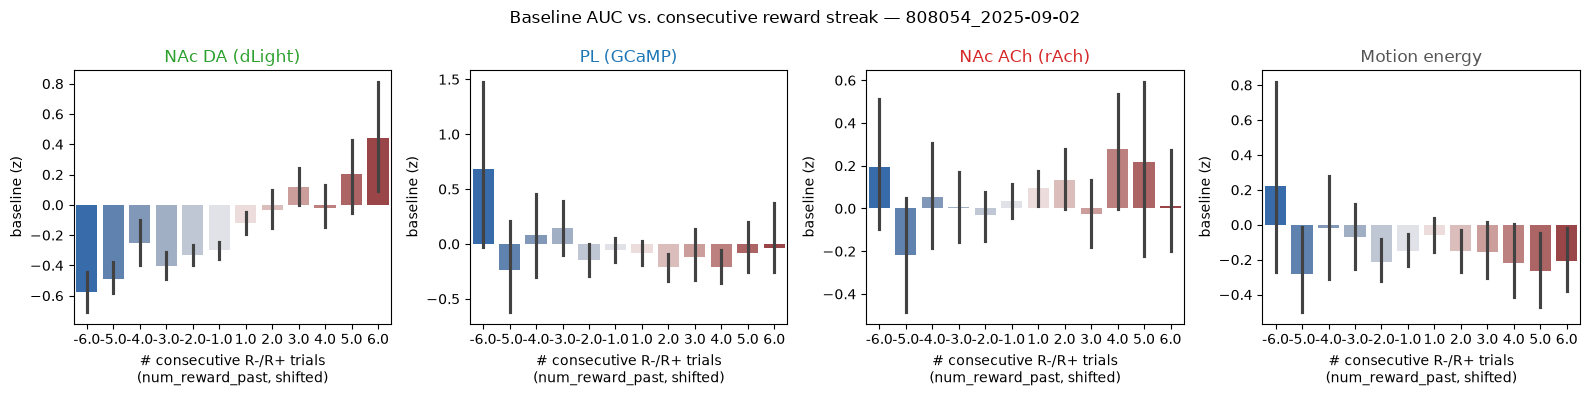

In [11]:
df_trials["num_reward_past_baseline"] = df_trials["num_reward_past"].shift(1)
df_bl = df_trials.query("num_reward_past_baseline > -7 and num_reward_past_baseline < 7")

baseline_signals = (
    [(ex["label"], f"data_z_{ex['event']}_baseline", ex["color"]) for ex in examples]
    + [("Motion energy", "data_z_ME_baseline", "#555555")]
)

fig, axes = plt.subplots(1, len(baseline_signals), figsize=(4 * len(baseline_signals), 4))
for ax, (label, col, color) in zip(np.atleast_1d(axes), baseline_signals):
    assert col in df_trials.columns, f"missing {col}"
    sns.barplot(x="num_reward_past_baseline", y=col, data=df_bl,
               palette="vlag", hue="num_reward_past_baseline", dodge=False, ax=ax)
    ax.legend().remove()
    ax.set_xlabel("# consecutive R-/R+ trials\n(num_reward_past, shifted)")
    ax.set_ylabel("baseline (z)")
    ax.set_title(label, color=color)
fig.suptitle(f"Baseline AUC vs. consecutive reward streak — {nwb.session_id}")
fig.tight_layout()
plt.show()